# [LAB-10] 2-2. 결과보고 모듈화 - 연습문제

## 당신은 미국 국립 당뇨병·소화기·신장질환 연구소(NIDDK)의 신입 분석가입니다.

연구소는 애리조나주 피마(Pima) 부족 거주 지역에서 오랫동안 당뇨병 역학조사를 진행해 왔습니다.
이번에 넘겨받은 자료는 **21세 이상 여성 768명**의 검진 기록으로,
각 참가자의 **포도당 부하 검사 수치(Glucose)** 와 **당뇨 판정 여부(1: 당뇨, 0: 정상)** 가 함께 기록되어 있는 **pima_indians_diabetes** 데이터셋 입니다.\

연구 책임자가 묻습니다.

> "혈당 수치 하나만 보고도 당뇨 위험을 얼마나 설명할 수 있습니까?
> 혈당이 조금 올라가면 당뇨일 확률은 얼마나 더 높아지는지, **논문에 실을 수 있는 문장과 표**로 정리해 주세요."

그래서 당신은 `Glucose` 하나만 독립변수로 쓰는 **단순 로지스틱 회귀** 모형을 적합하여 결과를 분석하기로 합니다.

## 코드 작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import Markdown, display

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 및 전처리

피마 인디언 당뇨병 데이터를 가져온다.

앞선 아이리스 예제에서는 종속변수가 문자열(`versicolor`, `virginica`)이라 `my_prep.labeling()`으로 0/1 변환이 필요했지만,
이 데이터의 `Outcome`은 **이미 0(정상) / 1(당뇨)의 숫자**로 저장되어 있으므로 라벨링 과정이 필요 없다.

In [2]:
origin = load_data("pima_indians_diabetes")
origin.head()

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


### 3. 분석에 사용할 변수만 추출

**단순** 로지스틱 회귀이므로 독립변수는 `Glucose` 하나만 사용한다.

In [3]:
df = origin[['Glucose', 'Outcome']]
df.head()

,Glucose,Outcome
0,148,1
1,85,0
2,183,1
3,89,0
4,137,1


### 4. 탐색적 데이터 분석

모형을 적합하기 전에 종속변수의 분포와, 두 집단의 혈당 차이를 먼저 눈으로 확인한다.

Outcome
0    500
1    268
Name: count, dtype: int64


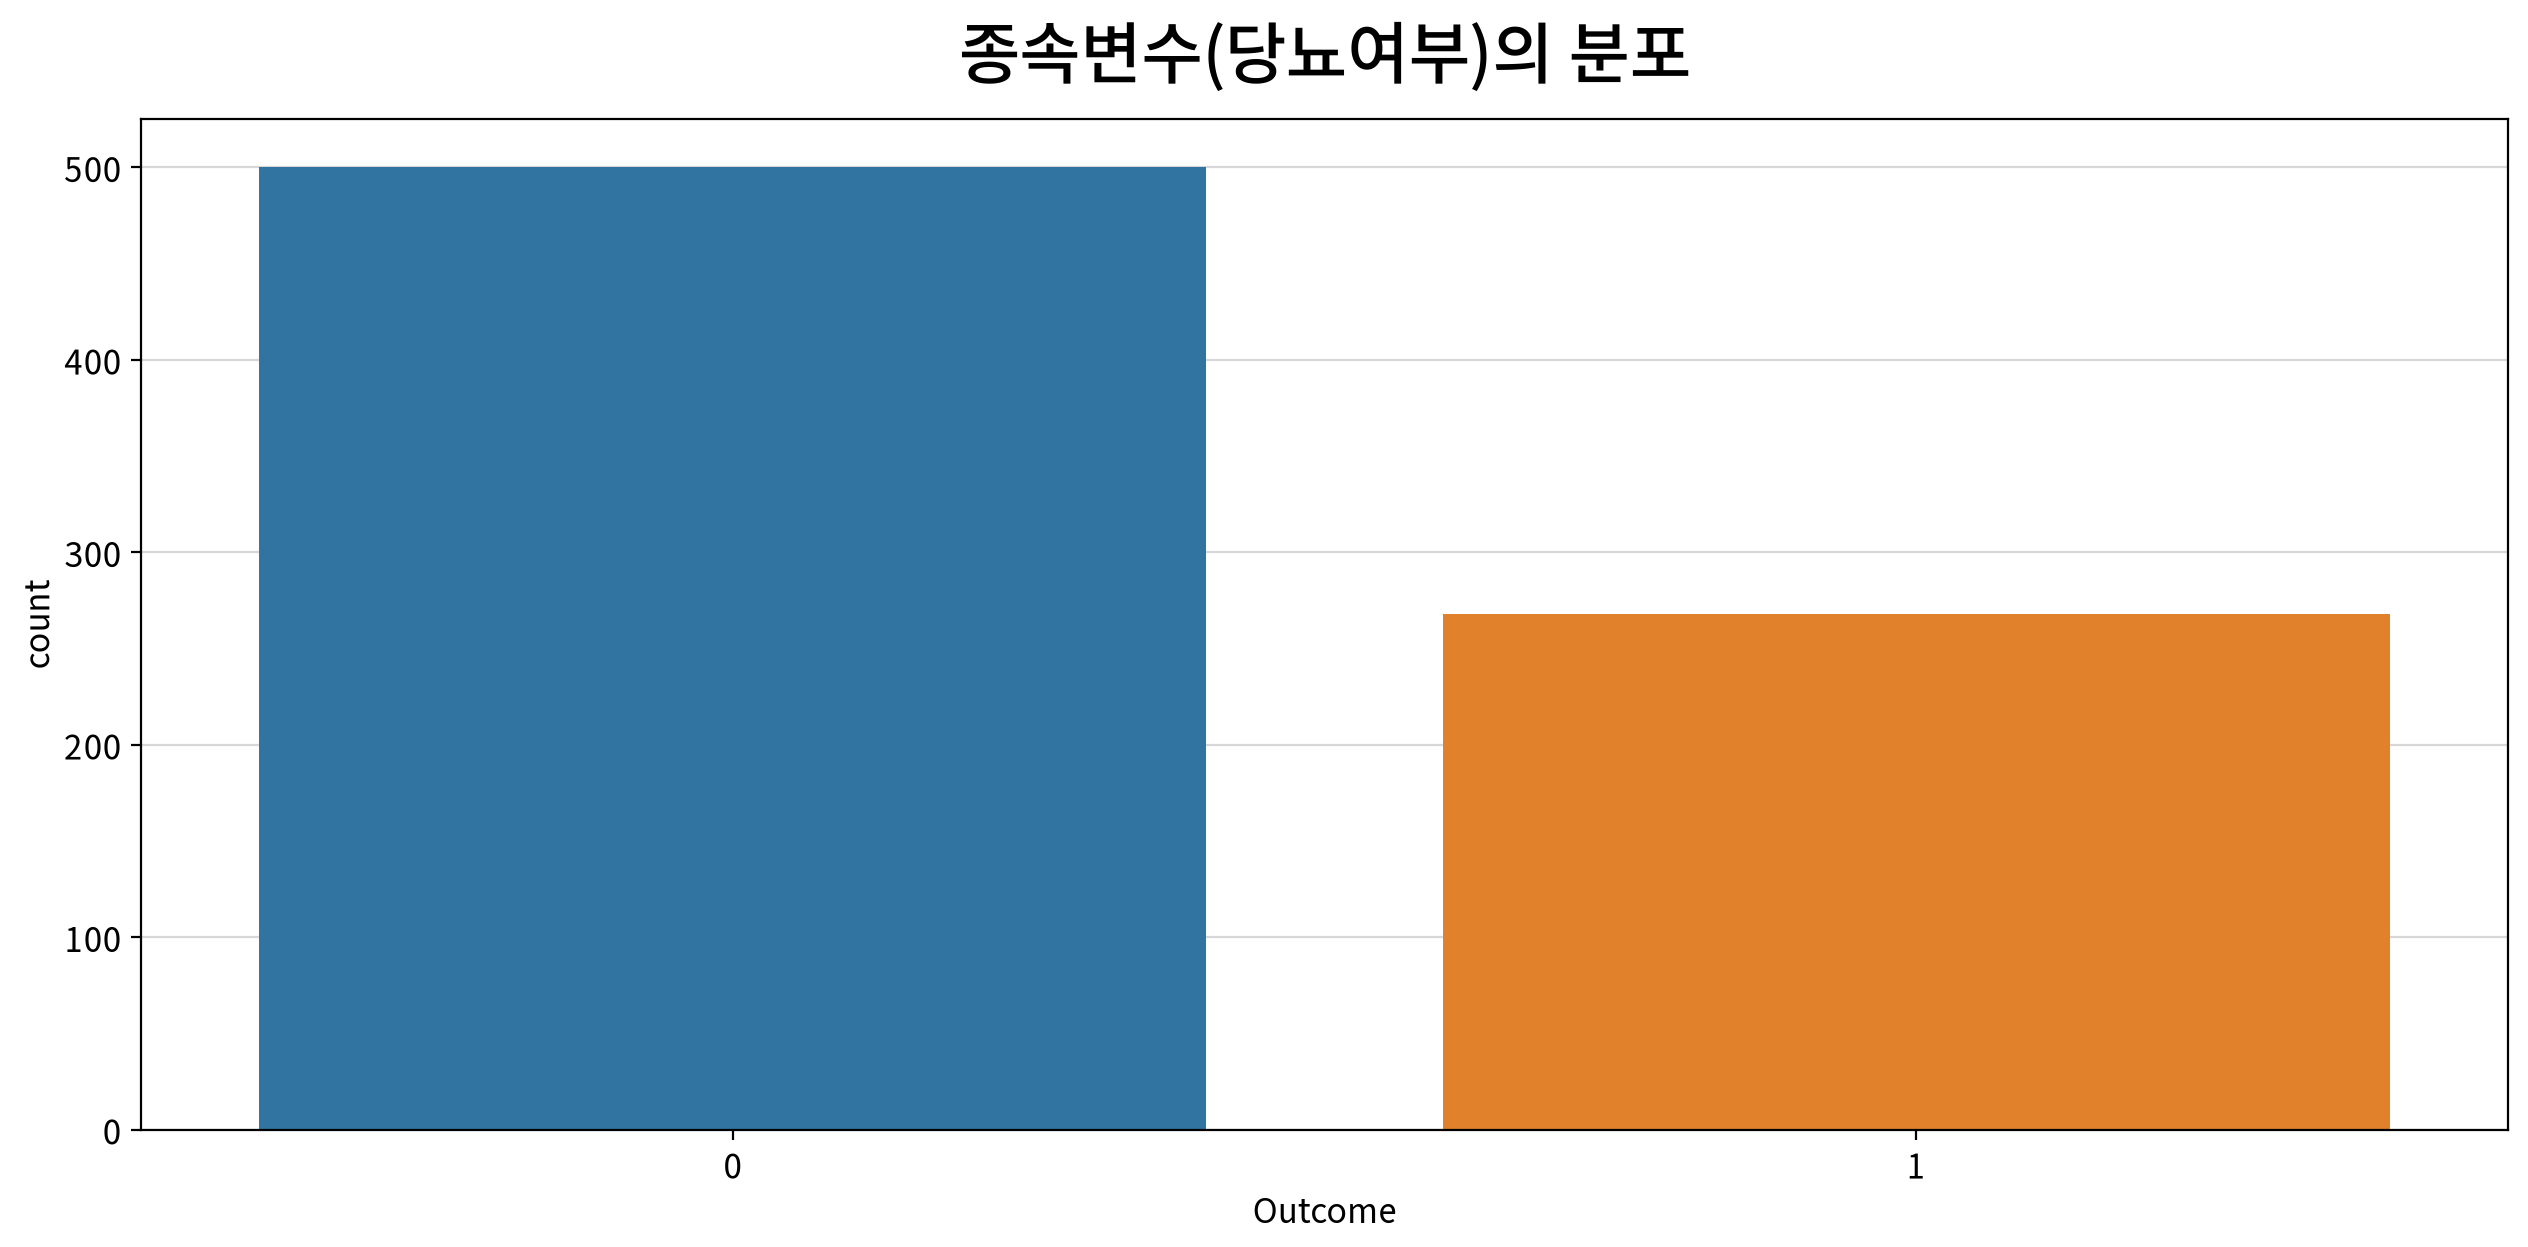

In [4]:
print(df['Outcome'].value_counts())
my_plot.countplot(df, x='Outcome', hue='Outcome', title='종속변수(당뇨여부)의 분포')

Outcome
0   109.980
1   141.257
Name: Glucose, dtype: float64


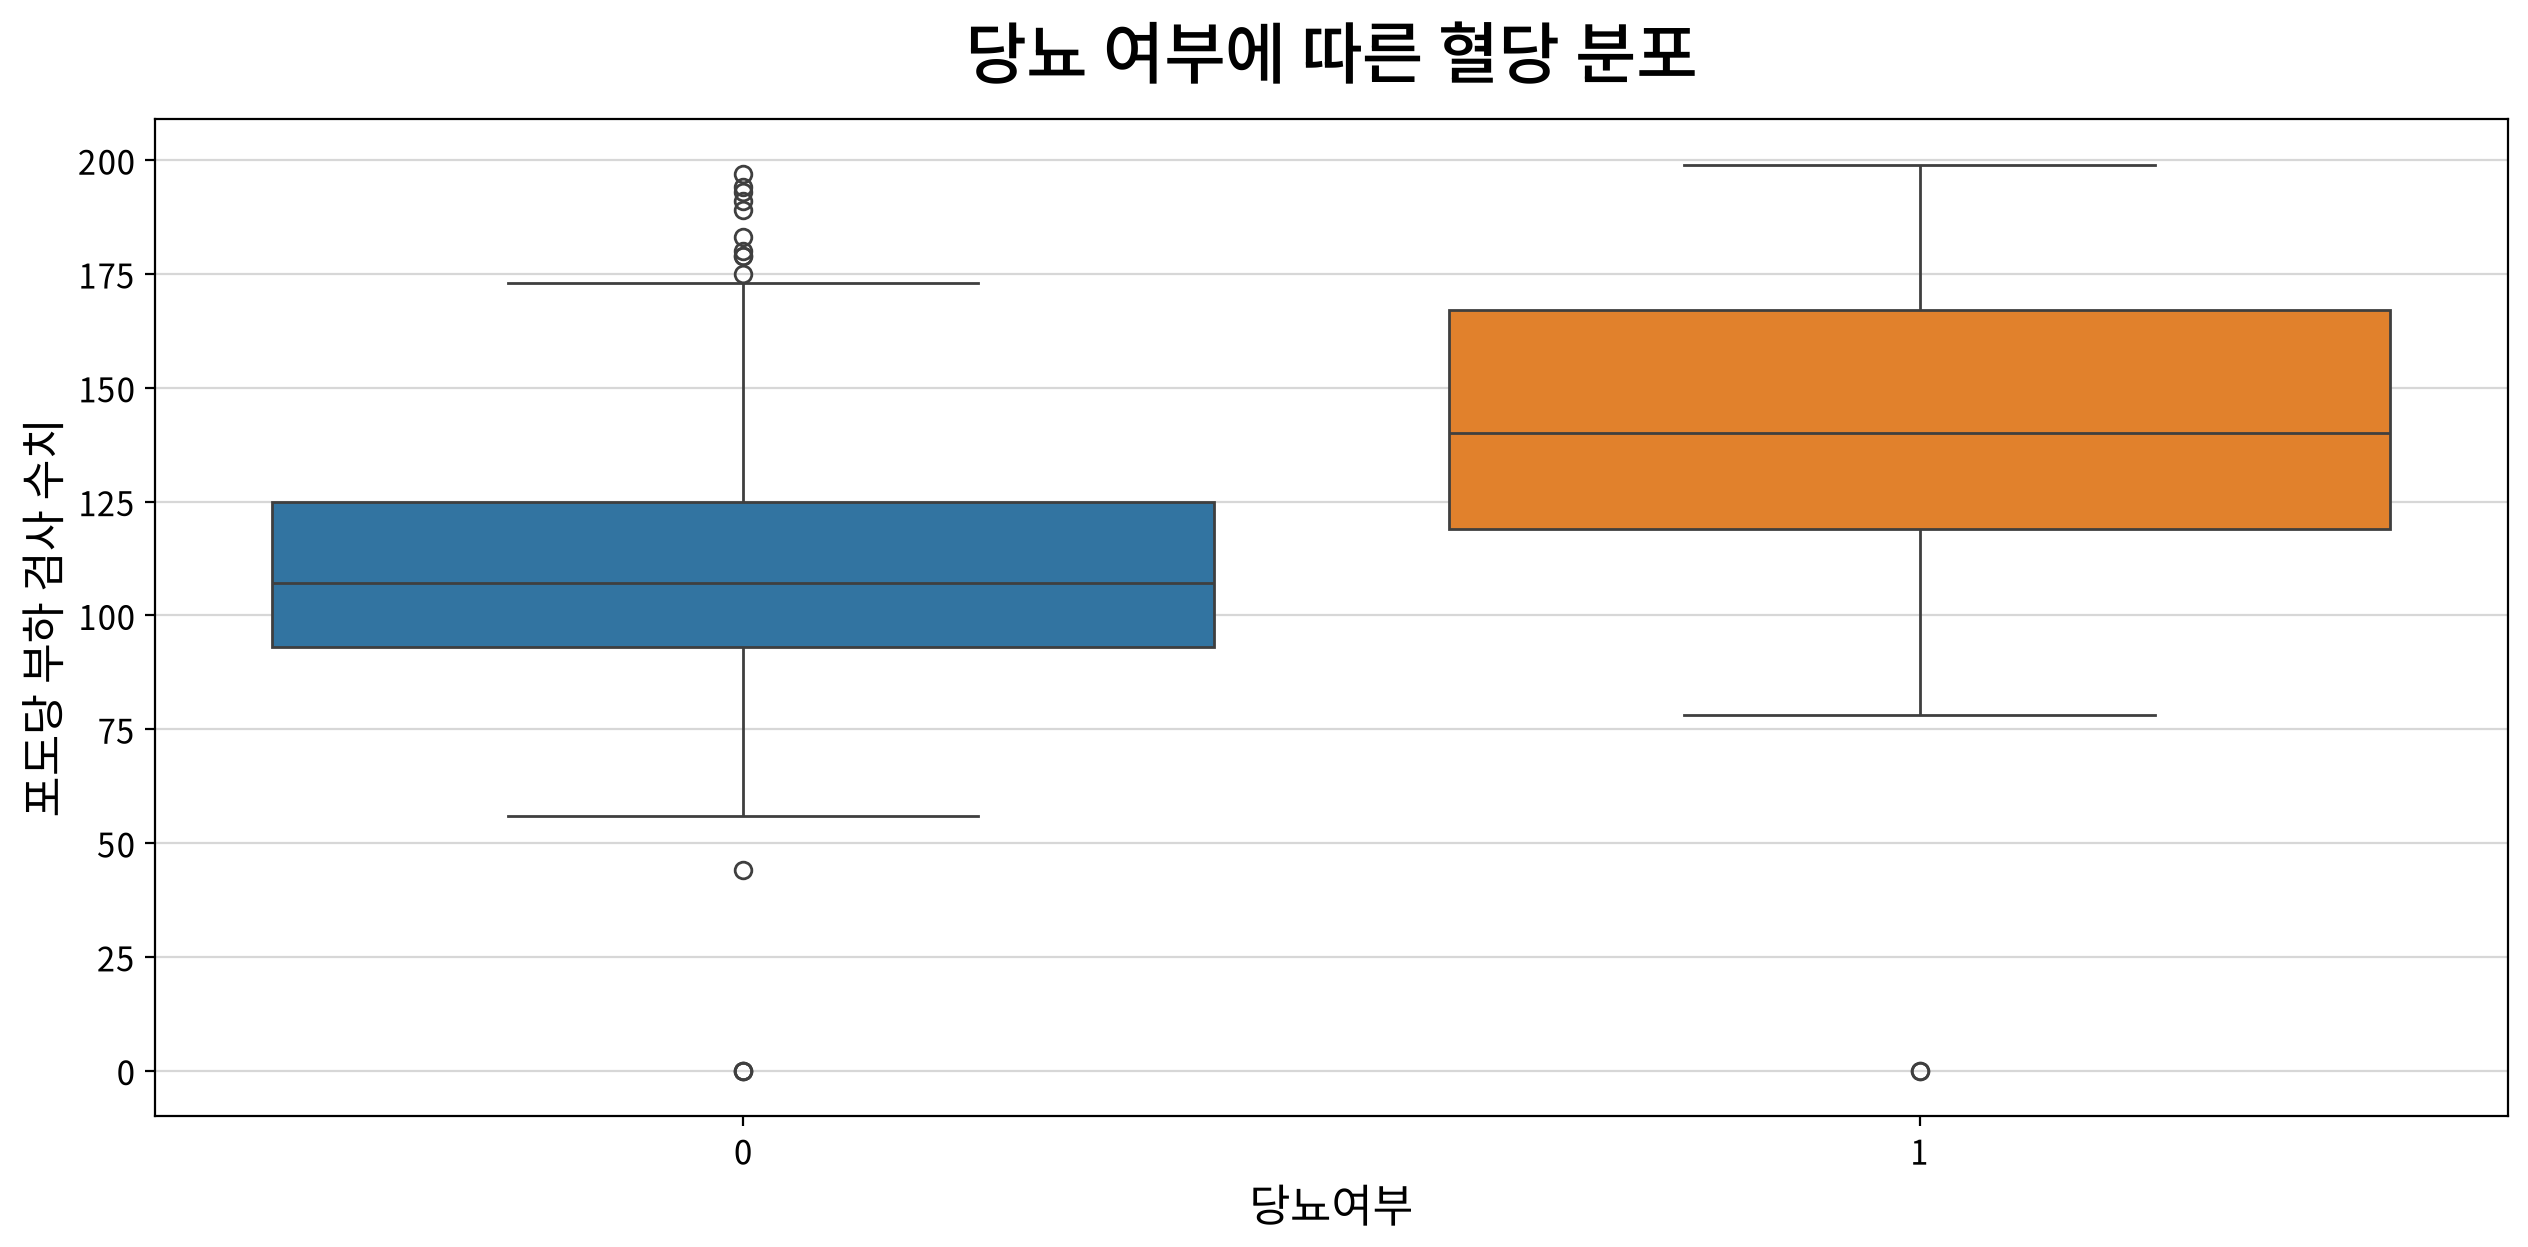

In [5]:
print(df.groupby('Outcome')['Glucose'].mean())

my_plot.boxplot(df, x='Outcome', y='Glucose', hue='Outcome',
                title='당뇨 여부에 따른 혈당 분포', xlabel='당뇨여부', ylabel='포도당 부하 검사 수치')

### 5. 단순 로지스틱 회귀 모형 적합

- 이 결과에서 모형 적합도에 필요한 정보를 추출하고 오즈를 계산해야 한다.

In [6]:
fit1 = my_logit.fit_model(df, y='Outcome', summary=True)

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.1860
Time:                        06:34:20   Log-Likelihood:                -404.36
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 4.418e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3501      0.421    -12.713      0.000      -6.175      -4.525
Glucose        0.0379      0.003     11.647      0.000       0.031       0.044


### 6. 모형 적합도

`summary()` 표에 흩어져 있는 LL, LLR χ², Pseudo R² 를 **보고서 문장**으로 자동 정리한다.

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,Glucose,0.038,1.211,0.003,11.647,0.000,1.039,1.032,1.045,1.000,1.000


**Note. n = 768. LL = -404.36, LL-Null = -496.742, LLR χ²(1) = 184.764, p < 0.001, Pseudo R² = 0.186**

Outcome를 종속변수로, Glucose(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(1) = 184.764, p < 0.001, Pseudo R² = 0.186.

즉, 모형의 유사결정계수는 0.186로 양호한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

- **Glucose**의 회귀계수는 **B = 0.0379**, 오즈비는 **OR = 1.0386**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 11.65**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.9% 증가**하는 것으로 해석된다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

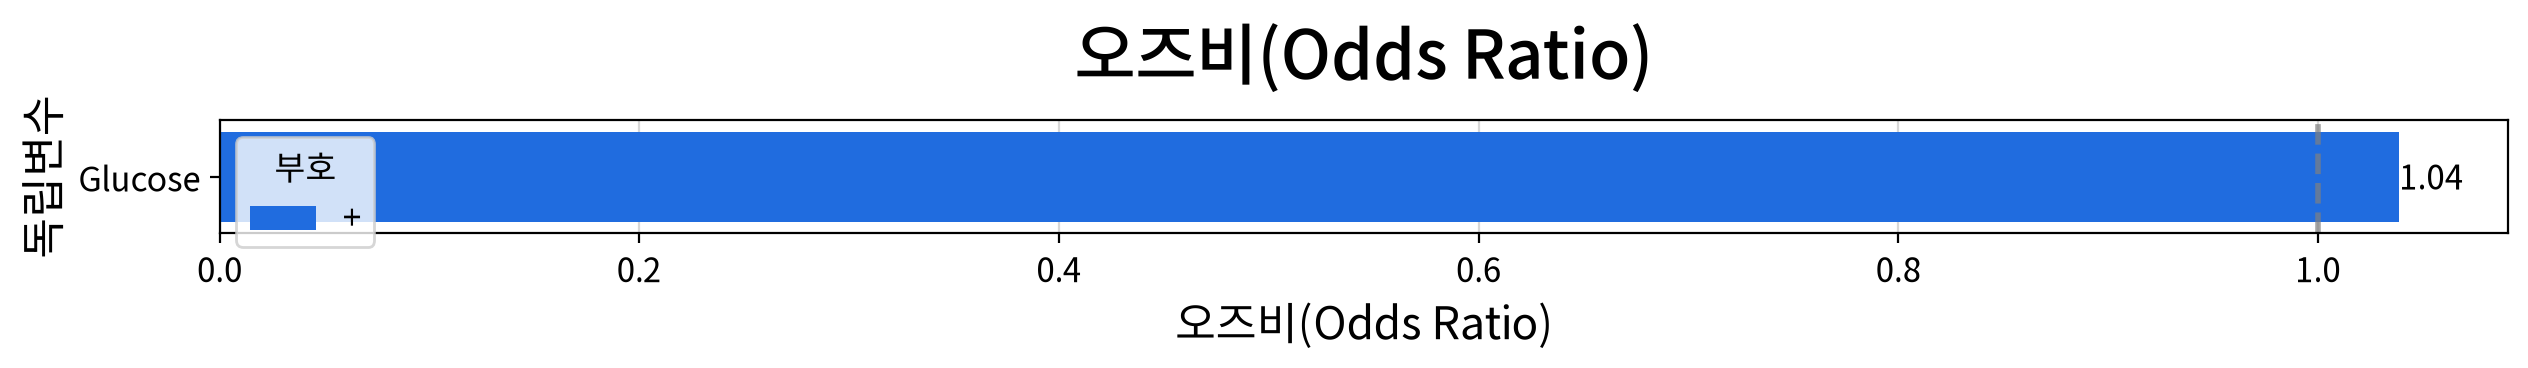

In [7]:
# 독립변수 보고 표
display(my_logit.report_variables(fit1, df))

# 모형 적합도 보고
display(Markdown(my_logit.report_fitness(fit1)))

# 모형 해석
display(Markdown(my_logit.report_variables_text(fit1, data=df)))

# 오즈비 시각화
my_logit.plot_odds(fit1, df, title='오즈비(Odds Ratio)', height=200)

## 문제 풀이

### 정답 요약

| 문항 | 정답 |
|:---:|:---|
| Q1 | **0(정상), 500명** |
| Q2 | **약 141.3 (정상 집단은 약 110.0)** |
| Q3 | **0.186** |
| Q4 | **1.039 (약 3.9% 증가)** |
| Q5 | **포함하지 않는다 → 유의하다** |
| Q6 | **약 1.466배** |

### Q1.

종속변수 `Outcome`의 두 범주(0/1) 중 **관측치(사람 수)가 더 많은** 값은 무엇이고, 그 인원은 몇 명인가?

#### 풀이: **0(정상), 500명**

`df['Outcome'].value_counts()` 를 실행하면 `0 → 500`, `1 → 268` 이 나온다. `countplot`의 막대 높이로도 0쪽이 더 높음을 확인할 수 있다.

전체 768명 중 당뇨 판정은 268명으로 약 **34.9%** 다. 한쪽이 90% 이상을 차지하는 심한 불균형은 아니므로 그대로 로지스틱 회귀를 적합해도 되지만, 나중에 **분류 성능을 볼 때는 정확도(accuracy)만 믿으면 안 된다**는 점을 기억해 두자. 무조건 "정상"이라고만 찍어도 정확도가 65%는 나오기 때문이다.

```python
df['Outcome'].value_counts()
```

### Q2.

당뇨 판정을 받은 집단(1)의 **평균 혈당(Glucose)** 은 얼마인가? (소수 첫째 자리까지)

#### 풀이: **약 141.3** (정상 집단은 약 110.0)

`df.groupby('Outcome')['Glucose'].mean()` 결과는 다음과 같다.

| Outcome | 평균 Glucose |
|:---:|---:|
| 0 (정상) | 109.98 |
| 1 (당뇨) | 141.26 |

두 집단의 평균이 **약 31 정도 차이**난다. `boxplot`에서도 당뇨(1) 상자가 위쪽(높은 혈당)에 위치한다.
"혈당이 높을수록 당뇨일 가능성이 크다"는 가설이 데이터에 실제로 담겨 있다는 뜻이고, 그래서 `Glucose` 하나만으로도 모형을 세워 볼 만하다고 판단할 수 있다.

```python
df.groupby('Outcome')['Glucose'].mean()
```

### Q3.

이 모형의 **Pseudo R²** 값은 얼마인가? (소수 셋째 자리까지)

#### 풀이: **0.186**

모형 적합도 보고문에 `LLR χ²(1) = 184.764, p < 0.001, Pseudo R² = 0.186` 으로 표시된다.

- `LLR p-value`가 0.001보다 훨씬 작으므로, **혈당을 넣은 모형이 아무것도 넣지 않은 모형(LL-Null)보다 유의하게 낫다.**
- Pseudo R² = 0.186은 선형회귀의 R²처럼 "18.6%를 설명한다"고 읽으면 **안 된다.** 로지스틱에서는 보통 0.2~0.4면 매우 우수한 적합으로 보므로, 0.186은 **변수 하나치고는 상당히 양호한 수준**이다.

### Q4.

`Glucose`의 **오즈비(OR)** 는 얼마이며, 이를 한 문장으로 어떻게 해석하는가?

#### 풀이: **1.039 → 혈당이 1 오를 때 당뇨 오즈가 약 3.9% 증가한다.**

표의 회귀계수 B = **0.038**(정확히는 0.03787)이고, 오즈비는 이를 지수변환한 값이다.

$$OR = e^{B} = e^{0.03787} = 1.039$$

여기서 주의할 점 두 가지가 있다.

1. **오즈비는 "확률"이 아니라 "오즈"의 배수**다. 확률이 3.9% 늘어난다는 뜻이 아니라, `p/(1-p)` 값이 1.039배가 된다는 뜻이다.
2. **1을 기준으로 읽는다.** OR > 1이면 위험을 높이는 변수, OR < 1이면 낮추는 변수, OR = 1이면 영향이 없다. 여기서는 1.039 > 1이므로 혈당은 **위험 요인**이다.

```python
import numpy as np
np.exp(fit1.params['Glucose'])   # 1.0386
```

### Q5.

`Glucose`의 **오즈비 95% 신뢰구간**은 1을 포함하는가? 그 사실이 의미하는 바는 무엇인가?

#### 풀이: **포함하지 않는다 (1.032 ~ 1.045) → 통계적으로 유의하다.**

보고표의 `OR 95% 하한 = 1.032`, `OR 95% 상한 = 1.045`로, 구간 전체가 1보다 크다.

오즈비 신뢰구간이 **1을 걸치면** "영향이 없을 가능성(OR=1)"을 배제할 수 없어 유의하지 않다고 판단한다. 반대로 여기처럼 구간이 1의 위쪽에만 있으면, 혈당의 효과 방향이 **양(+)으로 확정**된 것이다. 유의확률 p < 0.001 과 같은 결론이며, `plot_odds()` 그림에서 막대와 오차막대가 **OR=1 기준선 오른쪽에만** 놓이는 것으로도 확인된다.

### Q6.

혈당이 **10 증가**하면 당뇨 오즈는 몇 배가 되는가? (소수 둘째 자리까지)

#### 풀이: **약 1.46배**

오즈비는 "1단위 증가"에 대한 값이므로, 10단위 증가는 계수에 10을 곱한 뒤 지수변환한다.

$$e^{B \times 10} = e^{0.03787 \times 10} = e^{0.3787} = 1.46$$

주의할 점은 **1.039 × 10 = 10.39배가 아니라는 것**이다. 오즈비는 더하는 게 아니라 **곱해서 누적**된다(1.039를 10번 곱하면 1.46). 실제 임상에서 의미 있는 차이인 **혈당 30 증가**로 계산하면 $e^{0.03787 \times 30} = 3.11$ 배가 되어, 앞서 본 두 집단의 평균 차이(약 31)가 오즈 3배 수준의 격차임을 알 수 있다.

```python
import numpy as np
np.exp(fit1.params['Glucose'] * 10)   # 1.4604
np.exp(fit1.params['Glucose'] * 30)   # 3.1149
```